# 03 - Visualizacion y diagnostico de variables V2 binaria

Este notebook revisa calidad de datos y seleccion preliminar de variables antes del modelado.

Incluye:

- nulos
- cardinalidad
- correlacion numerica
- multicolinealidad con VIF
- variables recomendadas, con cuidado y excluidas


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.style.use("seaborn-v0_8-whitegrid")

RUTA_ACTUAL = Path.cwd().resolve()
RUTA_MODELO = None
for candidata in [RUTA_ACTUAL, *RUTA_ACTUAL.parents]:
    if (candidata / "V2" / "DATOS_PROCESADOS").exists() and candidata.name.lower() == "modelo":
        RUTA_MODELO = candidata
        break
    if (candidata / "modelo" / "V2" / "DATOS_PROCESADOS").exists():
        RUTA_MODELO = candidata / "modelo"
        break
if RUTA_MODELO is None:
    raise FileNotFoundError("No se encontro modelo/V2/DATOS_PROCESADOS")

RUTA_V2 = RUTA_MODELO / "V2"
RUTA_PROCESADOS = RUTA_V2 / "DATOS_PROCESADOS"
RUTA_GRAFICAS = RUTA_V2 / "GRAFICAS"
RUTA_GRAFICAS.mkdir(parents=True, exist_ok=True)

RUTA_DATASET = RUTA_PROCESADOS / "09_dataset_v2_multibacteria_balanceado_organismo_clase.csv"
print(RUTA_DATASET)


D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\V2\DATOS_PROCESADOS\09_dataset_v2_multibacteria_balanceado_organismo_clase.csv


## 1. Cargar dataset recomendado

In [2]:
df = pd.read_csv(RUTA_DATASET, low_memory=False)
print(df.shape)
print(df["susceptibility"].value_counts())
print(df["organism"].value_counts())
df.head()


(242923, 69)
susceptibility
Susceptible    150000
Resistant       92923
Name: count, dtype: int64
organism
ESCHERICHIA COLI          50000
KLEBSIELLA PNEUMONIAE     45624
STAPHYLOCOCCUS AUREUS     42866
ENTEROCOCCUS SPECIES      37242
PROTEUS MIRABILIS         36731
PSEUDOMONAS AERUGINOSA    30460
Name: count, dtype: int64


,anon_id,pat_enc_csn_id_coded,order_proc_id_coded,order_time_jittered_utc,ordering_mode,culture_description,organism,antibiotic,susceptibility,age,...,exp_prev_tetracycline,exp_prev_urinary_antiseptic,comorb_chronic_pulmonary_any,comorb_congestive_heart_failure,comorb_diabetes_any,comorb_organ_transplant_status,comorb_pancreatic_disorder,comorb_renal_failure,comorb_sinusitis,comorb_solid_tumor_non_metastatic
0,JC1466131,131262759980,591206288,2019-02-08 19:47:00+00:00,Null,URINE,ESCHERICHIA COLI,Amikacin,Susceptible,35-44 years,...,0,0,0,1,0,0,0,0,0,0
1,JC6319015,131340453889,819574108,2022-08-31 09:05:00+00:00,Inpatient,URINE,PROTEUS MIRABILIS,Ceftriaxone,Susceptible,75-84 years,...,0,0,0,1,1,0,0,0,0,0
2,JC2001249,131237232404,533224864,2017-07-14 22:14:00+00:00,Outpatient,URINE,KLEBSIELLA PNEUMONIAE,Cefoxitin,Susceptible,75-84 years,...,0,0,1,1,0,0,0,0,1,0
3,JC2909850,131280584151,643491973,2020-01-06 06:59:00+00:00,Inpatient,URINE,ESCHERICHIA COLI,Cefazolin,Susceptible,25-34 years,...,0,0,0,0,0,0,0,0,0,0
4,JC2155246,131239597994,539581654,2017-11-03 04:29:00+00:00,Inpatient,BLOOD,PSEUDOMONAS AERUGINOSA,Amikacin,Susceptible,35-44 years,...,0,0,0,1,0,0,0,0,0,0


## 2. Nulos y cardinalidad

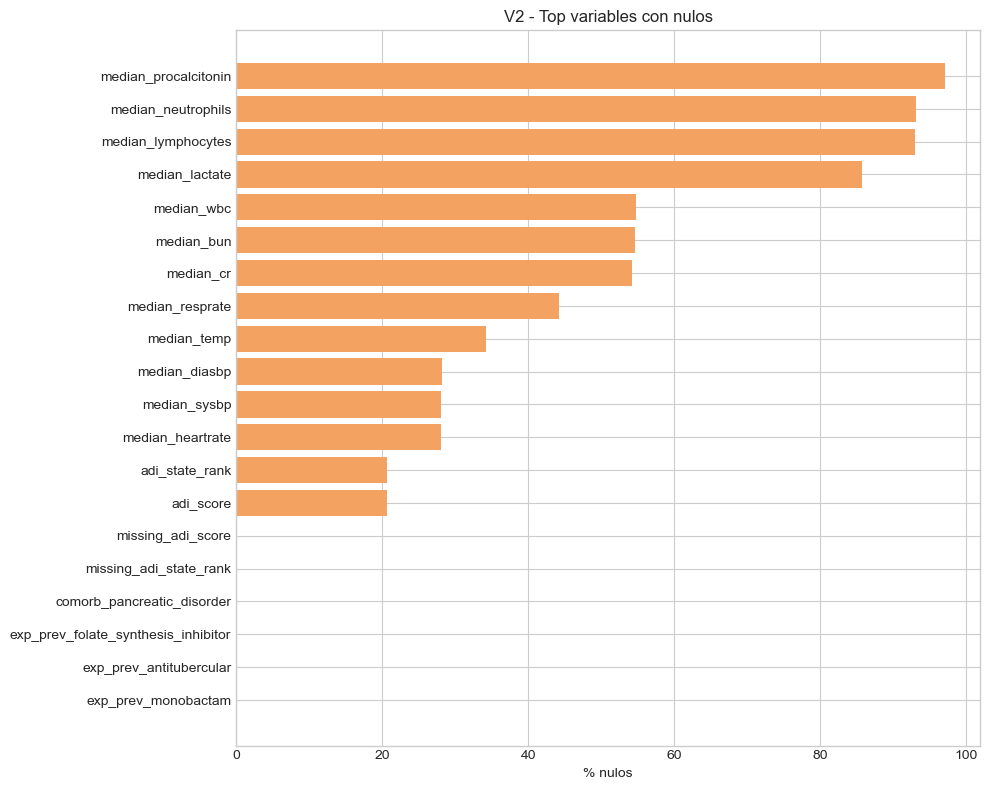

,variable,tipo,porcentaje_nulos,cardinalidad,porcentaje_valor_mayoritario
23,median_procalcitonin,float64,97.047212,531,97.047212
18,median_neutrophils,float64,93.162854,353,93.162854
19,median_lymphocytes,float64,93.060352,314,93.060352
22,median_lactate,float64,85.716462,643,85.716462
17,median_wbc,float64,54.741626,453,54.741626
20,median_bun,float64,54.698814,153,54.698814
21,median_cr,float64,54.243114,775,54.243114
13,median_resprate,float64,44.207012,46,44.207012
14,median_temp,float64,34.158561,150,34.158561
16,median_diasbp,float64,28.135253,115,28.135253


In [3]:
columnas_excluir_modelo = ["anon_id", "pat_enc_csn_id_coded", "order_proc_id_coded", "order_time_jittered_utc"]
variables_predictoras = [c for c in df.columns if c not in columnas_excluir_modelo + ["susceptibility"]]

perfil = []
for col in variables_predictoras:
    perfil.append({
        "variable": col,
        "tipo": str(df[col].dtype),
        "porcentaje_nulos": float(df[col].isna().mean() * 100),
        "cardinalidad": int(df[col].nunique(dropna=True)),
        "porcentaje_valor_mayoritario": float(df[col].value_counts(dropna=False, normalize=True).iloc[0] * 100),
    })
perfil = pd.DataFrame(perfil).sort_values(["porcentaje_nulos", "porcentaje_valor_mayoritario"], ascending=False)
perfil.to_csv(RUTA_PROCESADOS / "13_perfil_variables_v2.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_nulos = perfil.sort_values("porcentaje_nulos", ascending=False).head(20)
ax.barh(top_nulos["variable"], top_nulos["porcentaje_nulos"], color="#f4a261")
ax.invert_yaxis()
ax.set_title("V2 - Top variables con nulos")
ax.set_xlabel("% nulos")
fig.tight_layout()
fig.savefig(RUTA_GRAFICAS / "10_v2_top_nulos_variables.png", dpi=220, bbox_inches="tight")
plt.show()
perfil.head(20)


## 3. Correlacion numerica y relacion con target

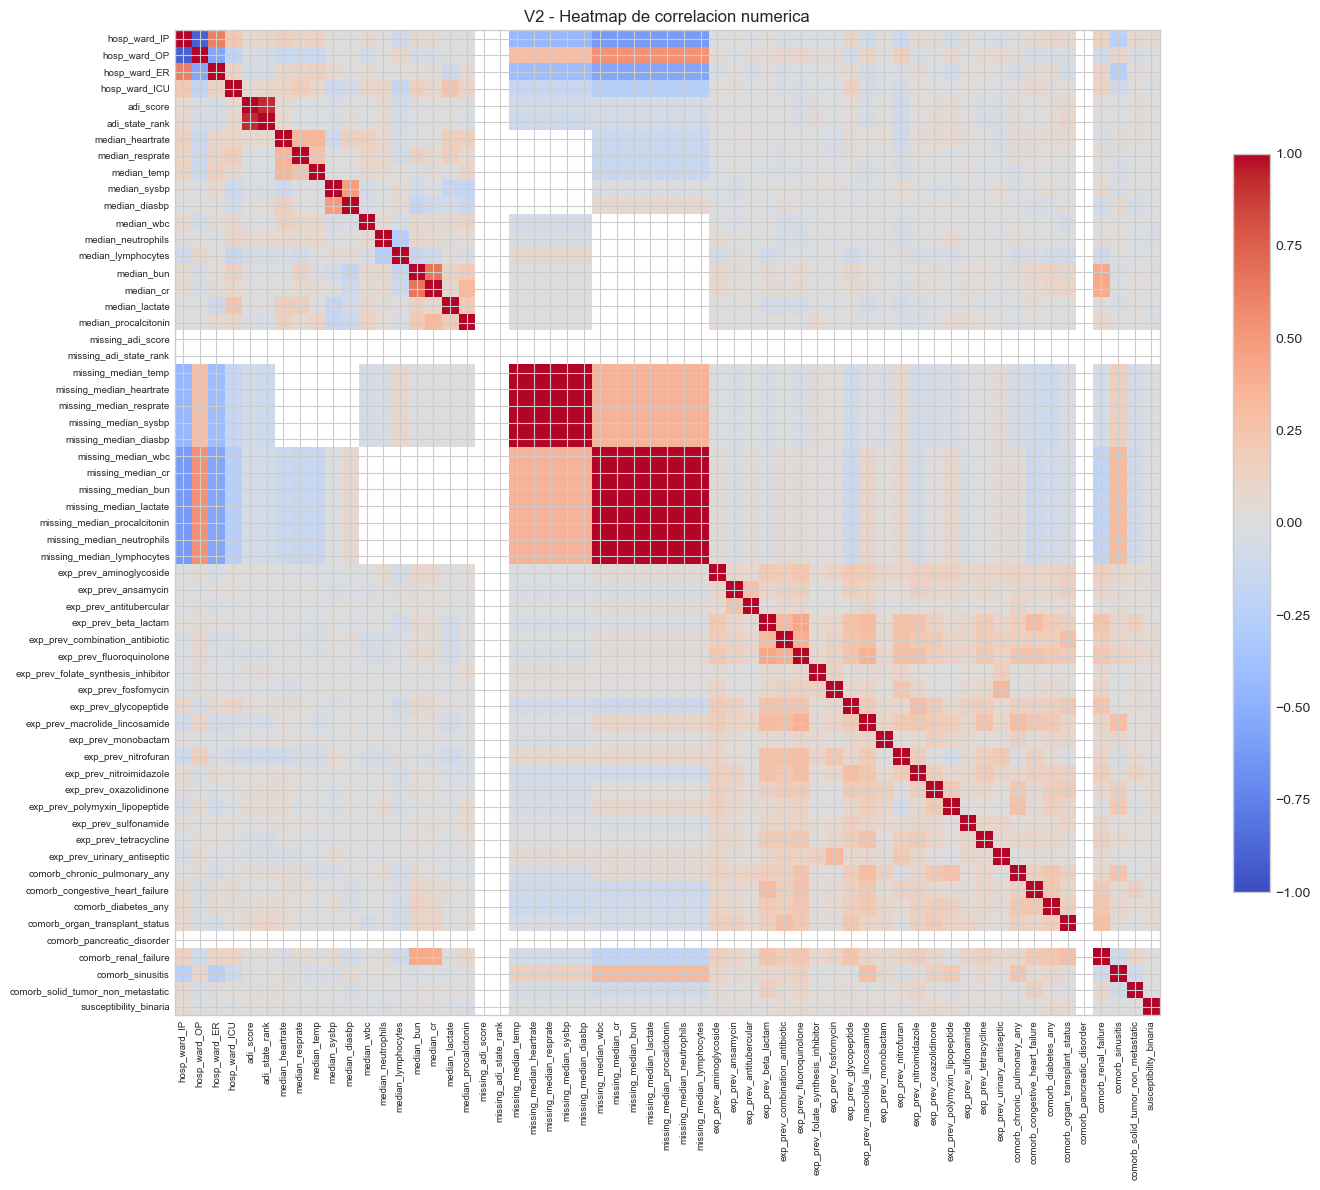

,correlacion_target,abs_correlacion_target
exp_prev_oxazolidinone,0.073657,0.073657
comorb_organ_transplant_status,0.063523,0.063523
comorb_diabetes_any,0.061951,0.061951
exp_prev_fluoroquinolone,0.054771,0.054771
exp_prev_combination_antibiotic,0.050834,0.050834
hosp_ward_IP,0.048610,0.048610
exp_prev_nitroimidazole,0.044712,0.044712
median_procalcitonin,-0.043826,0.043826
median_neutrophils,-0.041776,0.041776
exp_prev_polymyxin_lipopeptide,0.041120,0.041120


In [4]:
df_corr = df[variables_predictoras + ["susceptibility"]].copy()
df_corr["susceptibility_binaria"] = df_corr["susceptibility"].map({"Susceptible": 0, "Resistant": 1})
num_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "susceptibility_binaria"]

corr = df_corr[num_cols + ["susceptibility_binaria"]].corr(numeric_only=True)
corr.to_csv(RUTA_PROCESADOS / "14_matriz_correlacion_numerica_v2.csv")

corr_target = corr[["susceptibility_binaria"]].drop(index="susceptibility_binaria").rename(columns={"susceptibility_binaria": "correlacion_target"})
corr_target["abs_correlacion_target"] = corr_target["correlacion_target"].abs()
corr_target = corr_target.sort_values("abs_correlacion_target", ascending=False)
corr_target.to_csv(RUTA_PROCESADOS / "15_correlacion_numericas_con_target_v2.csv")

fig, ax = plt.subplots(figsize=(16, 12))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.index, fontsize=7)
ax.set_title("V2 - Heatmap de correlacion numerica")
fig.colorbar(im, ax=ax, shrink=0.75)
fig.tight_layout()
fig.savefig(RUTA_GRAFICAS / "11_v2_heatmap_correlacion_numerica.png", dpi=220, bbox_inches="tight")
plt.show()
corr_target.head(20)


## 4. Multicolinealidad con VIF

In [5]:
# VIF solo para variables numericas no binarias y con suficientes datos.
cols_vif = []
for col in num_cols:
    serie = pd.to_numeric(df[col], errors="coerce")
    if serie.nunique(dropna=True) > 2 and serie.isna().mean() < 0.8:
        cols_vif.append(col)

if len(cols_vif) >= 2:
    muestra_vif = df[cols_vif].copy()
    muestra_vif = muestra_vif.fillna(muestra_vif.median(numeric_only=True))
    if len(muestra_vif) > 50000:
        muestra_vif = muestra_vif.sample(50000, random_state=42)
    matriz = muestra_vif.to_numpy(dtype=float)
    vif = []
    for i, col in enumerate(cols_vif):
        try:
            valor = variance_inflation_factor(matriz, i)
        except Exception:
            valor = np.nan
        vif.append({"variable": col, "vif": valor})
    df_vif = pd.DataFrame(vif).sort_values("vif", ascending=False)
else:
    df_vif = pd.DataFrame(columns=["variable", "vif"])

df_vif.to_csv(RUTA_PROCESADOS / "16_vif_variables_numericas_v2.csv", index=False)
df_vif.head(20)


,variable,vif
4,median_temp,154.816127
5,median_sysbp,76.697091
3,median_resprate,68.876336
6,median_diasbp,64.017800
2,median_heartrate,40.415559
1,adi_state_rank,17.058765
0,adi_score,9.535483
8,median_bun,7.142468
9,median_cr,4.951052
7,median_wbc,3.439664


## 5. Decision preliminar de variables

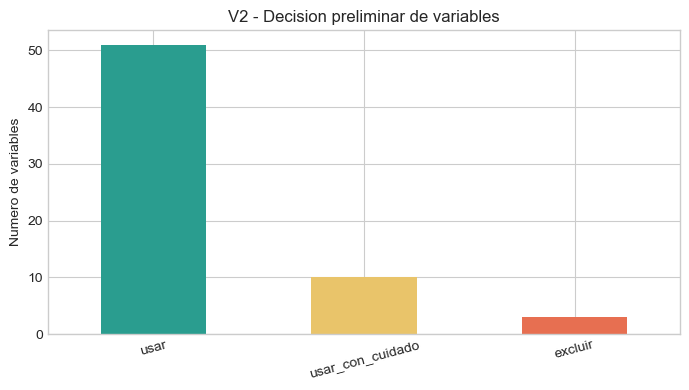

,variable,decision,motivo
0,ordering_mode,usar,variable candidata para modelado
1,culture_description,usar,variable candidata para modelado
2,organism,usar,variable candidata para modelado
3,antibiotic,usar,variable candidata para modelado
4,age,usar,variable candidata para modelado
...,...,...,...
59,comorb_organ_transplant_status,usar,variable candidata para modelado
60,comorb_pancreatic_disorder,excluir,"identificador, constante o sin variabilidad util"
61,comorb_renal_failure,usar,variable candidata para modelado
62,comorb_sinusitis,usar,variable candidata para modelado


In [6]:
variables_excluir = set(columnas_excluir_modelo)
variables_cuidado = set()
variables_usar = set(variables_predictoras)

for _, row in perfil.iterrows():
    var = row["variable"]
    if row["porcentaje_nulos"] > 90:
        variables_cuidado.add(var)
    if row["porcentaje_valor_mayoritario"] > 99:
        variables_cuidado.add(var)
    if row["cardinalidad"] <= 1:
        variables_excluir.add(var)

for _, row in df_vif.iterrows():
    if pd.notna(row["vif"]) and row["vif"] > 10:
        variables_cuidado.add(row["variable"])

registros = []
for var in variables_predictoras:
    if var in variables_excluir:
        decision = "excluir"
        motivo = "identificador, constante o sin variabilidad util"
    elif var in variables_cuidado:
        decision = "usar_con_cuidado"
        motivo = "faltantes altos, valor dominante o posible multicolinealidad"
    else:
        decision = "usar"
        motivo = "variable candidata para modelado"
    registros.append({"variable": var, "decision": decision, "motivo": motivo})

df_decision_vars = pd.DataFrame(registros)
df_decision_vars.to_csv(RUTA_PROCESADOS / "17_decision_variables_v2.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
df_decision_vars["decision"].value_counts().plot(kind="bar", ax=ax, color=["#2a9d8f", "#e9c46a", "#e76f51"])
ax.set_title("V2 - Decision preliminar de variables")
ax.set_xlabel("")
ax.set_ylabel("Numero de variables")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(RUTA_GRAFICAS / "12_v2_decision_variables.png", dpi=220, bbox_inches="tight")
plt.show()
df_decision_vars


## 6. Cierre

El notebook `04` debe leer `17_decision_variables_v2.csv` y excluir variables marcadas como `excluir`. Las variables `usar_con_cuidado` pueden entrar al modelo, pero deben mencionarse como limitacion metodologica.
